# data preprocessing 
## we will start with one csv inspect check for other then combine the best 


1. Load & basic structure check

In [2]:
import pandas as pd
import numpy as np

csv_path = "/kaggle/input/human-activity-recognition-dataset/101.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (376417, 54)

Columns:
['timestamp', 'activity_id', 'heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'hand_orient_1', 'hand_orient_2', 'hand_orient_3', 'hand_orient_4', 'chest_temp', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'chest_orient_1', 'chest_orient_2', 'chest_orient_3', 'chest_orient_4', 'ankle_temp', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z', 'ankle_orient_1', 'ankle_orient_2', 'ankle_orient_3', 'ankle_orient_4']


2. check missing values

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0]

print("Missing values per column:")
print(missing)


Missing values per column:
heart_rate        342028
hand_temp           1454
hand_acc16_x        1454
hand_acc16_y        1454
hand_acc16_z        1454
hand_acc6_x         1454
hand_acc6_y         1454
hand_acc6_z         1454
hand_gyro_x         1454
hand_gyro_y         1454
hand_gyro_z         1454
hand_mag_x          1454
hand_mag_y          1454
hand_mag_z          1454
hand_orient_1       1454
hand_orient_2       1454
hand_orient_3       1454
hand_orient_4       1454
chest_temp           509
chest_acc16_x        509
chest_acc16_y        509
chest_acc16_z        509
chest_acc6_x         509
chest_acc6_y         509
chest_acc6_z         509
chest_gyro_x         509
chest_gyro_y         509
chest_gyro_z         509
chest_mag_x          509
chest_mag_y          509
chest_mag_z          509
chest_orient_1       509
chest_orient_2       509
chest_orient_3       509
chest_orient_4       509
ankle_temp          1327
ankle_acc16_x       1327
ankle_acc16_y       1327
ankle_acc16_z       132

3. activity distribution 


activity_id
0     126460
1      27187
2      23480
3      21717
4      22253
5      21265
6      23575
7      20265
12     15890
13     14899
16     22941
17     23573
24     12912
Name: count, dtype: int64


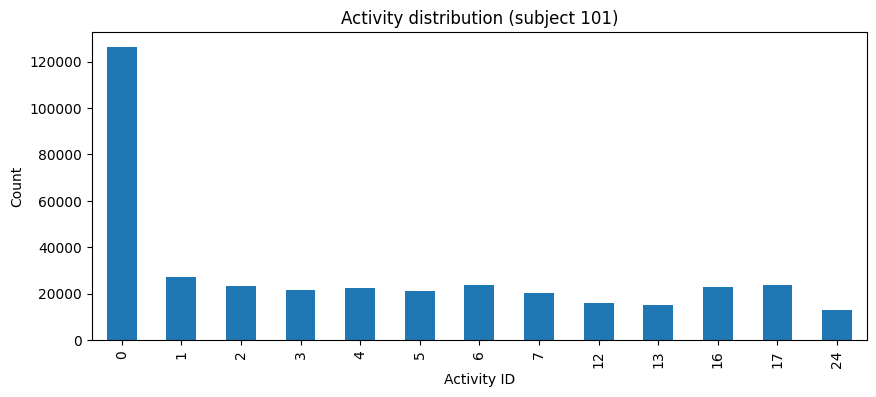

In [4]:
activity_counts = df["activity_id"].value_counts().sort_index()

print(activity_counts)

import matplotlib.pyplot as plt
activity_counts.plot(kind="bar", figsize=(10,4))
plt.title("Activity distribution (subject 101)")
plt.xlabel("Activity ID")
plt.ylabel("Count")
plt.show()


4. timestamp sanity check(time series integrity) 


In [5]:
print("Timestamp monotonic:", df["timestamp"].is_monotonic_increasing)

dt = df["timestamp"].diff().dropna()
print("Sampling interval stats:")
print(dt.describe())


Timestamp monotonic: True
Sampling interval stats:
count    3.764160e+05
mean     1.000000e-02
std      1.560567e-13
min      1.000000e-02
25%      1.000000e-02
50%      1.000000e-02
75%      1.000000e-02
max      1.000000e-02
Name: timestamp, dtype: float64


5. sensor value ranges(detect broken channels) 


In [6]:
sensor_cols = [c for c in df.columns if c not in ["timestamp", "activity_id", "heart_rate"]]

df[sensor_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
hand_temp,374963.0,32.429895,1.236379,30.00000,31.437500,32.812500,33.500000,33.87500
hand_acc16_x,374963.0,-3.349118,6.365465,-127.64900,-7.840210,-2.982460,1.669090,26.14580
hand_acc16_y,374963.0,6.278528,5.196436,-81.23440,3.591230,6.009140,8.621120,106.89800
hand_acc16_z,374963.0,3.407735,3.383241,-34.12480,1.502020,3.464280,5.551850,132.29500
hand_acc6_x,374963.0,-3.290532,6.395511,-56.98420,-7.718755,-2.923560,1.769210,19.11070
hand_acc6_y,374963.0,6.303530,5.217042,-42.79720,3.635865,6.049510,8.605695,62.06060
hand_acc6_z,374963.0,3.572275,3.369418,-22.05220,1.693380,3.674220,5.726600,53.61710
hand_gyro_x,374963.0,0.032741,1.072581,-11.25910,-0.344787,-0.001522,0.340209,16.48380
hand_gyro_y,374963.0,0.046213,0.870798,-22.21270,-0.218379,0.008506,0.287393,8.66664
hand_gyro_z,374963.0,0.002308,1.654828,-10.60880,-0.340880,-0.005281,0.339454,9.99862


6. zero-variance & near-zero features 



In [7]:
variances = df[sensor_cols].var()

zero_var = variances[variances == 0]
low_var = variances[variances < 1e-6]

print("Zero variance columns:")
print(zero_var.index.tolist())

print("\nNear-zero variance columns:")
print(low_var.index.tolist())


Zero variance columns:
['hand_orient_1', 'hand_orient_2', 'hand_orient_3', 'hand_orient_4', 'chest_orient_1', 'chest_orient_2', 'chest_orient_3', 'chest_orient_4', 'ankle_orient_1', 'ankle_orient_2', 'ankle_orient_3', 'ankle_orient_4']

Near-zero variance columns:
['hand_orient_1', 'hand_orient_2', 'hand_orient_3', 'hand_orient_4', 'chest_orient_1', 'chest_orient_2', 'chest_orient_3', 'chest_orient_4', 'ankle_orient_1', 'ankle_orient_2', 'ankle_orient_3', 'ankle_orient_4']


7. orientation validity check 


In [9]:
# based on recommendation dropped the ±6g channels,
import pandas as pd

# Drop orientation (invalid)
orient_cols = [c for c in df.columns if "orient" in c]

# Drop ±6g accelerometer
acc6_cols = [c for c in df.columns if "acc6" in c]

print("Dropping orientation columns:", orient_cols)
print("Dropping ±6g accelerometer columns:", acc6_cols)

df_clean = df.drop(columns=orient_cols + acc6_cols)

print("New shape:", df_clean.shape)
print("Remaining columns:")
print(df_clean.columns.tolist())


Dropping orientation columns: ['hand_orient_1', 'hand_orient_2', 'hand_orient_3', 'hand_orient_4', 'chest_orient_1', 'chest_orient_2', 'chest_orient_3', 'chest_orient_4', 'ankle_orient_1', 'ankle_orient_2', 'ankle_orient_3', 'ankle_orient_4']
Dropping ±6g accelerometer columns: ['hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z', 'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z']
New shape: (376417, 33)
Remaining columns:
['timestamp', 'activity_id', 'heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'chest_temp', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'ankle_temp', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z']


In [10]:
orient_cols = [c for c in df.columns if "orient" in c]

df[orient_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
hand_orient_1,374963.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
hand_orient_2,374963.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hand_orient_3,374963.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hand_orient_4,374963.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chest_orient_1,375908.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
chest_orient_2,375908.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chest_orient_3,375908.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chest_orient_4,375908.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ankle_orient_1,375090.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ankle_orient_2,375090.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


8. binary flag columns detection 


In [11]:
binary_cols = []

for c in df.columns:
    unique_vals = df[c].dropna().unique()
    if set(unique_vals).issubset({0,1}):
        binary_cols.append(c)

print("Binary columns:")
print(binary_cols)


Binary columns:
['hand_orient_1', 'hand_orient_2', 'hand_orient_3', 'hand_orient_4', 'chest_orient_1', 'chest_orient_2', 'chest_orient_3', 'chest_orient_4', 'ankle_orient_1', 'ankle_orient_2', 'ankle_orient_3', 'ankle_orient_4']


9. correlation check 

In [12]:
corr = df[sensor_cols].corr()

high_corr = [
    (c1, c2)
    for c1 in corr.columns
    for c2 in corr.columns
    if c1 != c2 and abs(corr.loc[c1, c2]) > 0.95
]

print("Highly correlated pairs (>0.95):")
print(high_corr[:10])


Highly correlated pairs (>0.95):
[('hand_acc16_x', 'hand_acc6_x'), ('hand_acc16_y', 'hand_acc6_y'), ('hand_acc16_z', 'hand_acc6_z'), ('hand_acc6_x', 'hand_acc16_x'), ('hand_acc6_y', 'hand_acc16_y'), ('hand_acc6_z', 'hand_acc16_z'), ('chest_acc16_x', 'chest_acc6_x'), ('chest_acc16_y', 'chest_acc6_y'), ('chest_acc16_z', 'chest_acc6_z'), ('chest_acc6_x', 'chest_acc16_x')]


# STEP 1 — Handle missing values

Strategy (defensible & standard):

IMUs → linear interpolation

Heart rate → forward-fill, then back-fill

In [13]:
df = df_clean.copy()

# Sort by time just in case
df = df.sort_values("timestamp")

# Interpolate IMU sensors
imu_cols = [c for c in df.columns 
            if c not in ["timestamp", "activity_id", "heart_rate"]]

df[imu_cols] = df[imu_cols].interpolate(method="linear")

# Heart rate (slow sensor)
df["heart_rate"] = df["heart_rate"].ffill().bfill()

print(df.isna().sum().sum(), "missing values remaining")


0 missing values remaining


# STEP 2 — Remove transient activity (activity_id = 0)
18 activity classes excluding transient

In [14]:
df = df[df["activity_id"] != 0]


# STEP 3 — Normalize sensor channels (CRITICAL)

In [15]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df.columns 
                if c not in ["timestamp", "activity_id"]]

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])


# STEP 4 — Sliding window segmentation
Windowing + Feature Extraction

In [21]:
import numpy as np
import pandas as pd

WINDOW_SIZE = 256
STEP_SIZE = 128

SENSOR_COLS = [
    'hand_acc16_x','hand_acc16_y','hand_acc16_z',
    'hand_gyro_x','hand_gyro_y','hand_gyro_z',
    'chest_acc16_x','chest_acc16_y','chest_acc16_z',
    'chest_gyro_x','chest_gyro_y','chest_gyro_z',
    'ankle_acc16_x','ankle_acc16_y','ankle_acc16_z',
    'ankle_gyro_x','ankle_gyro_y','ankle_gyro_z',
]

def extract_features(window):
    features = {}
    for col in SENSOR_COLS:
        x = window[col].values
        features[f'{col}_mean'] = np.mean(x)
        features[f'{col}_std'] = np.std(x)
        features[f'{col}_min'] = np.min(x)
        features[f'{col}_max'] = np.max(x)
        features[f'{col}_median'] = np.median(x)
        features[f'{col}_rms'] = np.sqrt(np.mean(x**2))
        features[f'{col}_iqr'] = np.percentile(x, 75) - np.percentile(x, 25)
    return features

X, y = [], []

for start in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
    window = df.iloc[start:start+WINDOW_SIZE]

    # skip windows with missing data
    if window[SENSOR_COLS].isna().any().any():
        continue

    label = window['activity_id'].mode()[0]
    feats = extract_features(window)

    X.append(feats)
    y.append(label)

X = pd.DataFrame(X)
y = pd.Series(y, name='activity_id')

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1951, 126)
y shape: (1951,)


# save cleaned dataset 

In [22]:
import os

# Make sure folders exist
os.makedirs("/kaggle/working/cleaned", exist_ok=True)

clean_path = "/kaggle/working/cleaned/subject101_clean.csv"
df_clean.to_csv(clean_path, index=False)

print(f"Cleaned dataset saved to: {clean_path}")


Cleaned dataset saved to: /kaggle/working/cleaned/subject101_clean.csv


# save windowed dataset

In [23]:
import pandas as pd
import os

os.makedirs("/kaggle/working/features", exist_ok=True)

# Convert features to DataFrame
X_df = pd.DataFrame(X)
X_df["activity_id"] = y

feature_path = "/kaggle/working/features/subject101_windows.csv"
X_df.to_csv(feature_path, index=False)

print(f"Windowed feature dataset saved to: {feature_path}")


Windowed feature dataset saved to: /kaggle/working/features/subject101_windows.csv
